**Integrate and Merge data**

In [18]:
import pandas as pd

# Load Excell Files
fact = pd.read_excel('FactSales.xlsx')
dim_customer = pd.read_excel('DimCustomer.xlsx')
dim_product = pd.read_excel('DimProduct.xlsx')
dim_shipping = pd.read_excel('DimShipping.xlsx')
dim_date = pd.read_excel('DimDate.xlsx')

df = fact.copy()


if 'Customer ID' not in dim_customer.columns:
    dim_customer.columns = ['Customer ID', 'Customer Name', 'Segment']

# Merge df and dim_customer
cust_subset = dim_customer[['Customer ID', 'Segment']].drop_duplicates(
    'Customer ID'
)
df = df.merge(cust_subset, on='Customer ID', how='left')

# Merge df and dim_product
prod_subset = dim_product[
    ['Product ID', 'Category', 'Sub-Category']
].drop_duplicates('Product ID')
df = df.merge(prod_subset, on='Product ID', how='left')

# Merge df and dim_shipping
shipping_subset = dim_shipping[
    ['Shipping ID', 'Country', 'Region', 'Ship Mode_N']
].drop_duplicates('Shipping ID')
df = df.merge(shipping_subset, on='Shipping ID', how='left')

# Merge df and dim_date
date_subset = dim_date[['Miladi', 'mmonthN', 'MquarterN']].drop_duplicates(
    'Miladi'
)
df = df.merge(
    date_subset, left_on='Order Date', right_on='Miladi', how='left'
).drop(columns=['Miladi'])

print(f'تعداد سطرهای جدول نهایی بعد از ادغام: {len(df)}')
print(f'ابعاد نهایی دیتافریم: {df.shape}')

df.to_csv('Integrated_Sales_Data.csv', index=False)

تعداد سطرهای جدول نهایی بعد از ادغام: 49670
ابعاد نهایی دیتافریم: (49670, 26)


**Feature Engineering**

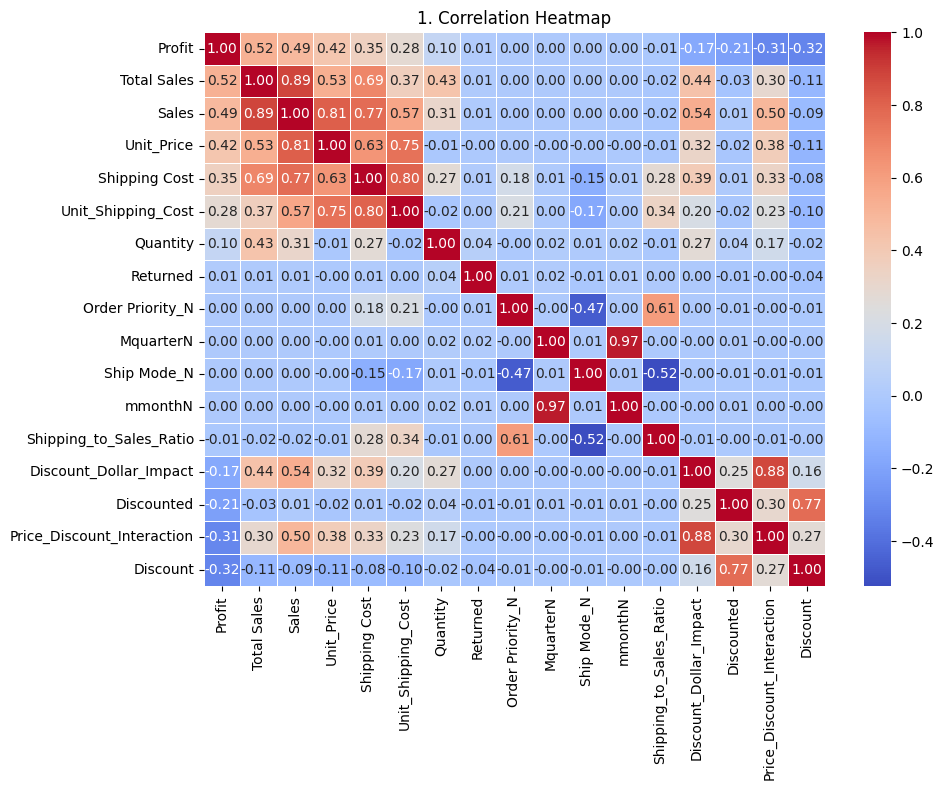

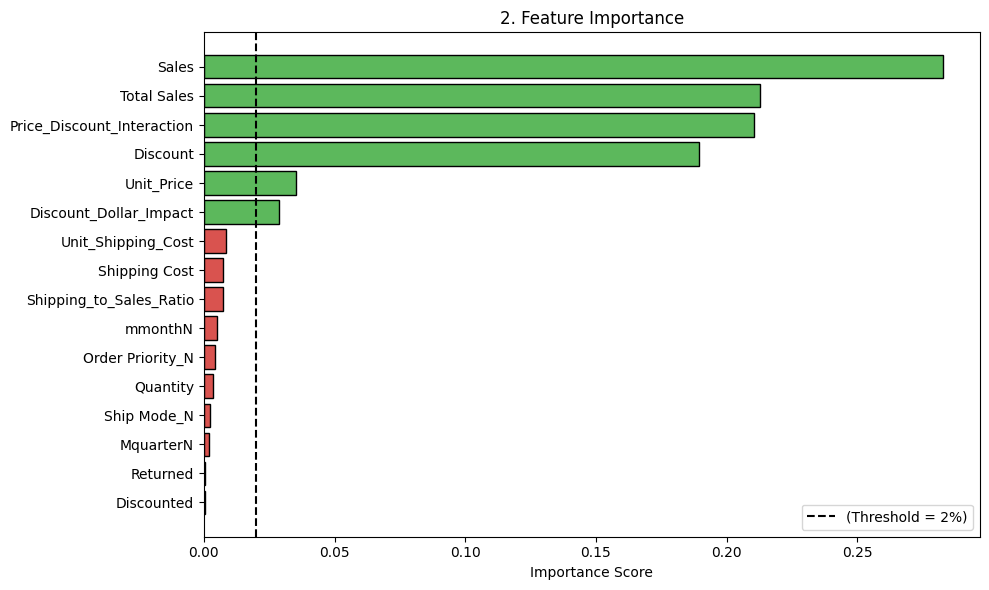

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor


df = pd.read_csv('Integrated_Sales_Data.csv')

# Define Some Columns
df['Unit_Price'] = df['Sales'] / (df['Quantity'] + 1e-5)
df['Unit_Shipping_Cost'] = df['Shipping Cost'] / (df['Quantity'] + 1e-5)
df['Discount_Dollar_Impact'] = df['Total Sales'] * df['Discount']
df['Price_Discount_Interaction'] = df['Sales'] * df['Discount']
df['Shipping_to_Sales_Ratio'] = df['Shipping Cost'] / (df['Sales'] + 1e-5)

# Delete Some Columns
drop_cols = [
    'Profitable',
    'Row ID',
    'Order ID',
    'Product ID',
    'Customer ID',
    'Shipping ID',
    'Order Date',
    'Order Priority',
]
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])


# Heat MAp
plt.figure(figsize=(10, 8))
numeric_df = df_clean.select_dtypes(include=[np.number])

corr = numeric_df.corr()
top_corr_features = corr['Profit'].sort_values(ascending=False).index

sns.heatmap(
    corr.loc[top_corr_features, top_corr_features],
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    cbar=True,
    linewidths=0.5,
)
plt.title(
    '1. Correlation Heatmap',
    fontsize=12,
)
plt.tight_layout()
plt.show()

# Feature Importance
X = numeric_df.drop(columns=['Profit'])
y = numeric_df['Profit']

rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X, y)


importance_df = pd.DataFrame(
    {'Feature': X.columns, 'Importance': rf.feature_importances_}
).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = [
    '#d9534f' if imp < 0.02 else '#5cb85c'
    for imp in importance_df['Importance']
]
bars = plt.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color=colors,
    edgecolor='black',
)

plt.axvline(
    x=0.02,
    color='black',
    linestyle='--',
    label='(Threshold = 2%)',
)
plt.title(
    '2. Feature Importance',
    fontsize=12,
)
plt.xlabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.show()

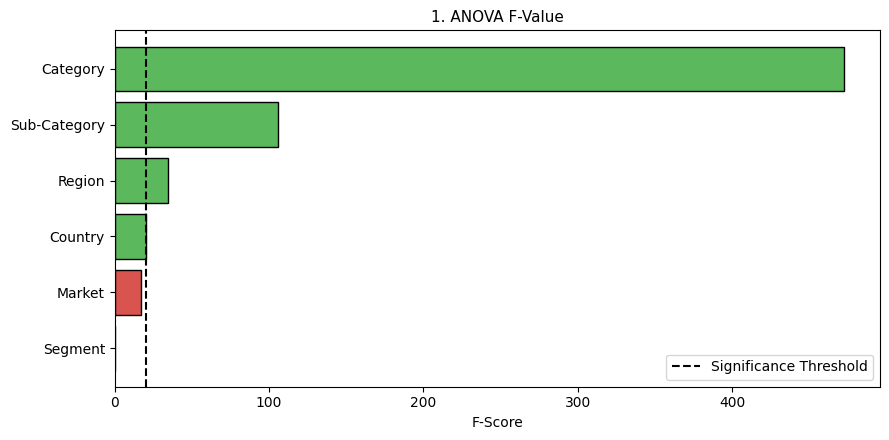

In [20]:
from sklearn.feature_selection import f_regression

df = pd.read_csv('Integrated_Sales_Data.csv')

cat_cols = ['Category', 'Sub-Category', 'Segment', 'Region', 'Country', 'Market']

# ANOVA F-Score
f_scores = {}
for col in cat_cols:
    if col in df.columns:
        encoded_col = pd.get_dummies(df[col], drop_first=True)
        # calculate f-score between profit and categorical column
        f_val, _ = f_regression(encoded_col, df['Profit'])
        f_scores[col] = np.mean(f_val)
cat_impact = pd.Series(f_scores).sort_values(ascending=True)

plt.figure(figsize=(9, 4.5))
colors = ['#5cb85c' if score >= 20 else '#d9534f' for score in cat_impact]
plt.barh(cat_impact.index, cat_impact.values, color=colors, edgecolor='black')
plt.axvline(
    x=20,
    color='black',
    linestyle='--',
    label='Significance Threshold',
)
plt.title(
    '1. ANOVA F-Value',
    fontsize=11,
)
plt.xlabel('F-Score')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Feature Selection
df = pd.read_csv('Integrated_Sales_Data.csv')

df['Unit_Price'] = df['Sales'] / (df['Quantity'] + 1e-5)
df['Price_Discount_Interaction'] = df['Sales'] * df['Discount']
df['Discount_Dollar_Impact'] = df['Total Sales'] * df['Discount']

# Select features based on plots
selected_numeric_cols = [
    'Total Sales',
    'Sales',
    'Unit_Price',
    'Shipping Cost',
    'Quantity',
    'Discount',
    'Discounted',
    'Price_Discount_Interaction',
    'Discount_Dollar_Impact',
]

selected_cat_cols = ['Category', 'Sub-Category', 'Region']

X_numeric = df[selected_numeric_cols]
X_cat = pd.get_dummies(df[selected_cat_cols], drop_first=True)

X = pd.concat([X_numeric, X_cat], axis=1)
y = df['Profit']

**Train-Validation Split**

In [22]:
# Year
df['Order_Year'] = pd.to_datetime(df['Order Date'], errors='coerce').dt.year

# Train and Validation
train_mask = df['Order_Year'] < 2014
val_mask = df['Order_Year'] == 2014

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

print(f'Train (before 2014): {len(X_train)} ')
print(f'Validation (2014): {len(X_val)}')

Train (before 2014): 32907 
Validation (2014): 16763


**Model Selection**

                Family / Algorithm  Validation R²   MAE   RMSE
    4. Boosting (GradientBoosting)         0.7530 33.88  85.69
                 1. Linear (Ridge)         0.6806 41.10  97.45
5. Boosting (HistGradientBoosting)         0.6644 35.39  99.89
        3. Bagging (Random Forest)         0.6450 35.11 102.73
    2. Single Tree (Decision Tree)         0.4921 37.60 122.88


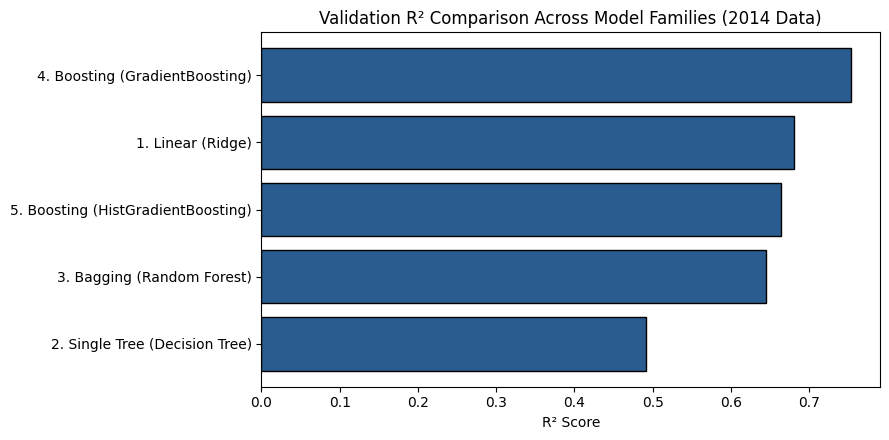

In [23]:
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

# Define Models
models = {
    '1. Linear (Ridge)': make_pipeline(
        StandardScaler(with_mean=False), Ridge(alpha=10.0)
    ),
    '2. Single Tree (Decision Tree)': DecisionTreeRegressor(
        max_depth=8, min_samples_leaf=20, random_state=42
    ),
    '3. Bagging (Random Forest)': RandomForestRegressor(
        n_estimators=150,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1,
    ),
    '4. Boosting (GradientBoosting)': GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42
    ),
    '5. Boosting (HistGradientBoosting)': HistGradientBoostingRegressor(
        max_iter=250,
        max_depth=6,
        min_samples_leaf=20,
        l2_regularization=2.0,
        random_state=42,
    ),
}

# Train and Results
metrics_summary = []

for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_val)

  r2 = r2_score(y_val, y_pred)
  mae = mean_absolute_error(y_val, y_pred)
  rmse = np.sqrt(mean_squared_error(y_val, y_pred))

  metrics_summary.append({
      'Family / Algorithm': name,
      'Validation R²': round(r2, 4),
      'MAE': round(mae, 2),
      'RMSE': round(rmse, 2),
  })

# Plot and Tables to compare
comparison_df = pd.DataFrame(metrics_summary).sort_values(
    by='Validation R²', ascending=False
)
print(comparison_df.to_string(index=False))

plt.figure(figsize=(9, 4.5))
plt.barh(
    comparison_df['Family / Algorithm'],
    comparison_df['Validation R²'],
    color='#2b5c8f',
    edgecolor='black',
)
plt.title('Validation R² Comparison Across Model Families (2014 Data)')
plt.xlabel('R² Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [24]:
from sklearn.model_selection import RandomizedSearchCV

# Search for hyperparameters
targeted_param_grid = {
    'n_estimators': [200, 300, 400, 500],
    'learning_rate': [0.03, 0.04, 0.05, 0.06],
    'max_depth': [5, 6, 7],
    'min_samples_split': [15, 25, 35],
    'min_samples_leaf': [8, 12, 16],
    'subsample': [0.85, 0.90, 0.95, 1.0], 
    'max_features': [
        None,
        0.9,
    ],
}

tuned_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=targeted_param_grid,
    n_iter=35,
    scoring='r2',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=1,
)

print('Search...')
tuned_search.fit(X_train, y_train)

# Finding Best Model
best_model_v2 = tuned_search.best_estimator_
y_val_v2 = best_model_v2.predict(X_val)

new_r2 = r2_score(y_val, y_val_v2)
new_mae = mean_absolute_error(y_val, y_val_v2)
new_rmse = np.sqrt(mean_squared_error(y_val, y_val_v2))

print('\n--- ‌Best HyperParameters ---')
for p, v in tuned_search.best_params_.items():
  print(f'  - {p}: {v}')

print('\n--- Comparison  ---')
print(f'Base R²: 0.7530   --->   New R²: {new_r2:.4f}')
print(f'Base MAE: 33.88   --->   New MAE: {new_mae:.2f}')
print(f'Base RMSE: 85.69  --->   New RMSE: {new_rmse:.2f}')

Search...
Fitting 3 folds for each of 35 candidates, totalling 105 fits

--- ‌Best HyperParameters ---
  - subsample: 0.85
  - n_estimators: 200
  - min_samples_split: 35
  - min_samples_leaf: 8
  - max_features: None
  - max_depth: 5
  - learning_rate: 0.03

--- Comparison  ---
Base R²: 0.7530   --->   New R²: 0.7026
Base MAE: 33.88   --->   New MAE: 35.61
Base RMSE: 85.69  --->   New RMSE: 94.03
